# <span style="font-size:35px; color: teal">**Análisis de absentismo y bienestar laboral - 08/06/2026**</span>

<span style="color: rgb(84, 101, 233); font-size:25px">**Desafio nº3: impacto fumador social y bebedor social**</span>

## <span style="font-size:20px; color:olive">**1. Pregunta de negocio**</span>

   - <span style="font-size:16px">**¿Cómo influyen el consumo social de alcohol o tabaco y los antecedentes disciplinarios en los niveles de absentismo?**


## <span style="font-size:20px; color:olive">**2. Dataset limpio utilizado y alcance mínimo**</span>

   - <span style="font-size:16px">Usamos el archivo limpio del corte `08/06/2026`. Esta parte no vuelve a hacer data cleaning; solo controla la muestra que entra en el análisis.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap

DATA_FILE = '../../Data/clean/clean_data_08062026.csv'
df_RRHH = pd.read_csv(DATA_FILE)


   - ### <span style="font-size:20px; color: orange">Control inicial del dataset</span>

<span style="font-size:14px">Antes de entrar en el análisis, revisamos tamaño, primeras filas y tipos de datos. Es una comprobación simple, pero ayuda a que el notebook sea trazable y no funcione como una caja negra.</span>


In [3]:
print('Filas y columnas:', df_RRHH.shape)
display(df_RRHH.head())
df_RRHH.info()


Filas y columnas: (1109, 28)


,ID,Reason_absence,Reason_absence_name,Month_absence,Month_absence_name,Day_week,Day_week_name,Seasons,Seasons_name,Transportation_expense,...,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,BMI_calculated,Absenteeism_hours,importacion
0,14,11.0,Sistema digestivo,5.0,Mayo,2,Lunes,2,Primavera,155,...,2,1,0,0,95,196,25,24.7,120,2026-05-25
1,36,13.0,Sistema musculoesquelético,10.0,Octubre,4,Miércoles,4,Otoño,118,...,1,1,0,0,98,178,31,30.9,120,2026-05-25
2,9,6.0,Sistema nervioso,1.0,Enero,3,Martes,1,Invierno,228,...,2,0,0,1,65,172,22,22.0,120,2026-05-25
3,28,9.0,Sistema circulatorio,1.0,Enero,3,Martes,1,Invierno,225,...,1,0,0,2,69,169,24,24.2,112,2026-05-25
4,9,12.0,Piel y tejido subcutáneo,9.0,Septiembre,3,Martes,3,Verano,228,...,2,0,0,1,65,172,22,22.0,112,2026-05-25


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1109 entries, 0 to 1108
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       1109 non-null   int64  
 1   Reason_absence           1042 non-null   float64
 2   Reason_absence_name      1042 non-null   object 
 3   Month_absence            1106 non-null   float64
 4   Month_absence_name       1106 non-null   object 
 5   Day_week                 1109 non-null   int64  
 6   Day_week_name            1109 non-null   object 
 7   Seasons                  1109 non-null   int64  
 8   Seasons_name             1109 non-null   object 
 9   Transportation_expense   1109 non-null   int64  
 10  Distance_Residence_Work  1109 non-null   int64  
 11  Service_time             1109 non-null   int64  
 12  Age                      1109 non-null   int64  
 13  Work_load_Average_day    1109 non-null   float64
 14  Hit_target              

In [4]:
alcance = pd.DataFrame({
    'métrica': [
        'registros limpios',
        'IDs observados',
        'horas totales de absentismo',
        'registros con ausencia > 0 horas'
    ],
    'valor': [
        len(df_RRHH),
        df_RRHH['ID'].nunique(),
        df_RRHH['Absenteeism_hours'].sum(),
        (df_RRHH['Absenteeism_hours'] > 0).sum()
    ]
})

alcance


,métrica,valor
0,registros limpios,1109
1,IDs observados,386
2,horas totales de absentismo,10155
3,registros con ausencia > 0 horas,1039


**Lectura:** el análisis trabaja con el clean consolidado del 01/06/2026. Las métricas describen la muestra disponible, no la plantilla completa de RapidExpress.


### <span style="font-size:18px; color:olive">**2.1 Generamos dataframe empleados** Agregamos por ID</span>

In [5]:
df_empleados = df_RRHH.groupby('ID', as_index=False).agg(
    registros=('ID', 'size'),
    horas_totales=('Absenteeism_hours', 'sum'),
    media_horas=('Absenteeism_hours', 'mean'),
    Age=('Age', 'first'),
    Education_name=('Education_name', 'first'),
    Son=('Son', 'first'),
    Pet=('Pet', 'first'),
    Social_drinker=('Social_drinker', 'first'),
    Social_smoker=('Social_smoker', 'first'),
    BMI_calculated=('BMI_calculated', 'first'),
    Service_time=('Service_time', 'first'),
    Distance_Residence_Work=('Distance_Residence_Work', 'first'),
    Transportation_expense=('Transportation_expense', 'first'),
    Work_load_Average_day=('Work_load_Average_day', 'median'),
    Hit_target=('Hit_target', 'median'),
    Disciplinary_failure=('Disciplinary_failure', 'max')
)
df_empleados.sort_values('horas_totales', ascending=False, inplace=True)
display(df_empleados.head())

,ID,registros,horas_totales,media_horas,Age,Education_name,Son,Pet,Social_drinker,Social_smoker,BMI_calculated,Service_time,Distance_Residence_Work,Transportation_expense,Work_load_Average_day,Hit_target,Disciplinary_failure
13,14,33,844,25.575758,34,Secundaria,2,0,1,0,24.7,14,12,155,284.031,97.0,0
8,9,12,726,60.500000,58,Secundaria,2,1,0,0,22.0,16,14,228,255.339,96.5,0
35,36,37,631,17.054054,50,Secundaria,1,0,1,0,30.9,18,13,118,253.957,95.0,1
27,28,78,571,7.320513,28,Secundaria,1,2,0,0,24.2,9,26,225,274.534,95.0,1
10,11,41,554,13.512195,33,Secundaria,2,1,1,0,30.4,13,36,289,265.017,94.0,1


In [6]:
df_empleados.count()

ID                         386
registros                  386
horas_totales              386
media_horas                386
Age                        386
Education_name             386
Son                        386
Pet                        386
Social_drinker             386
Social_smoker              386
BMI_calculated             386
Service_time               386
Distance_Residence_Work    386
Transportation_expense     386
Work_load_Average_day      386
Hit_target                 386
Disciplinary_failure       386
dtype: int64

## <span style="font-size:20px; color:olive">**3. Variables consideradas**</span>

   - <span style="font-size:14px">**Variables personales:** `Social_drinker`, `Social_smoker`.</span>
   - <span style="font-size:14px">**Variables laborales:** `Disciplinary_failure`.</span>

<span style="font-size:14px; color: rgb(50, 131, 203)"> **No estamos buscando “culpables” ni perfiles individuales cerrados. Estamos ordenando variables para ver dónde aparecen asociaciones y qué preguntas internas podría hacerse RRHH.**</span>


### <span style="font-size:18px; color:olive">**3.1. Tabla descriptiva de la pregunta de negocio**</span>

In [7]:
variables_habitos = [
    'Social_drinker',
    'Social_smoker',
    'Disciplinary_failure'
]

resumen_habitos = []

for variable in variables_habitos:

    tabla = (
        df_empleados
        .groupby(variable)
        .agg(
            empleados=('ID', 'nunique'),
            horas_totales=('horas_totales', 'sum'),
            media_horas=('horas_totales', 'mean'),
            mediana_horas=('horas_totales', 'median'),
            q1=('horas_totales', lambda x: x.quantile(0.25)),
            q3=('horas_totales', lambda x: x.quantile(0.75))
        )
        .reset_index()
    )

    tabla['variable'] = variable

    resumen_habitos.append(tabla)

resumen_habitos = pd.concat(resumen_habitos)

resumen_habitos

,Social_drinker,empleados,horas_totales,media_horas,mediana_horas,q1,q3,variable,Social_smoker,Disciplinary_failure
0,0.0,168,4203,25.017857,3.0,2.0,8.0,Social_drinker,NaN,NaN
1,1.0,218,5952,27.302752,4.0,2.0,8.0,Social_drinker,NaN,NaN
0,NaN,340,9539,28.055882,4.0,2.0,8.0,Social_smoker,0.0,NaN
1,NaN,46,616,13.391304,5.5,2.0,8.0,Social_smoker,1.0,NaN
0,NaN,341,6205,18.196481,4.0,2.0,8.0,Disciplinary_failure,NaN,0.0
1,NaN,45,3950,87.777778,0.0,0.0,73.0,Disciplinary_failure,NaN,1.0


In [8]:
# Diagrama de Venn 
#from matplotlib_venn import venn3
# Crear subconjuntos para el diagrama de Venn
set_smoker = set(df_empleados[df_empleados['Social_smoker'] == 1]['ID'])
set_disciplinary = set(df_empleados[df_empleados['Disciplinary_failure'] == 1]['ID'])
set_drinker = set(df_empleados[df_empleados['Social_drinker'] == 1]['ID'])
set_smoker_drinker = set_smoker.intersection(set_drinker)
set_smoker_disciplinary = set_smoker.intersection(set_disciplinary)
set_drinker_disciplinary = set_drinker.intersection(set_disciplinary)
set_absentismo = set(df_empleados[df_empleados['horas_totales'] > 0]['ID'])


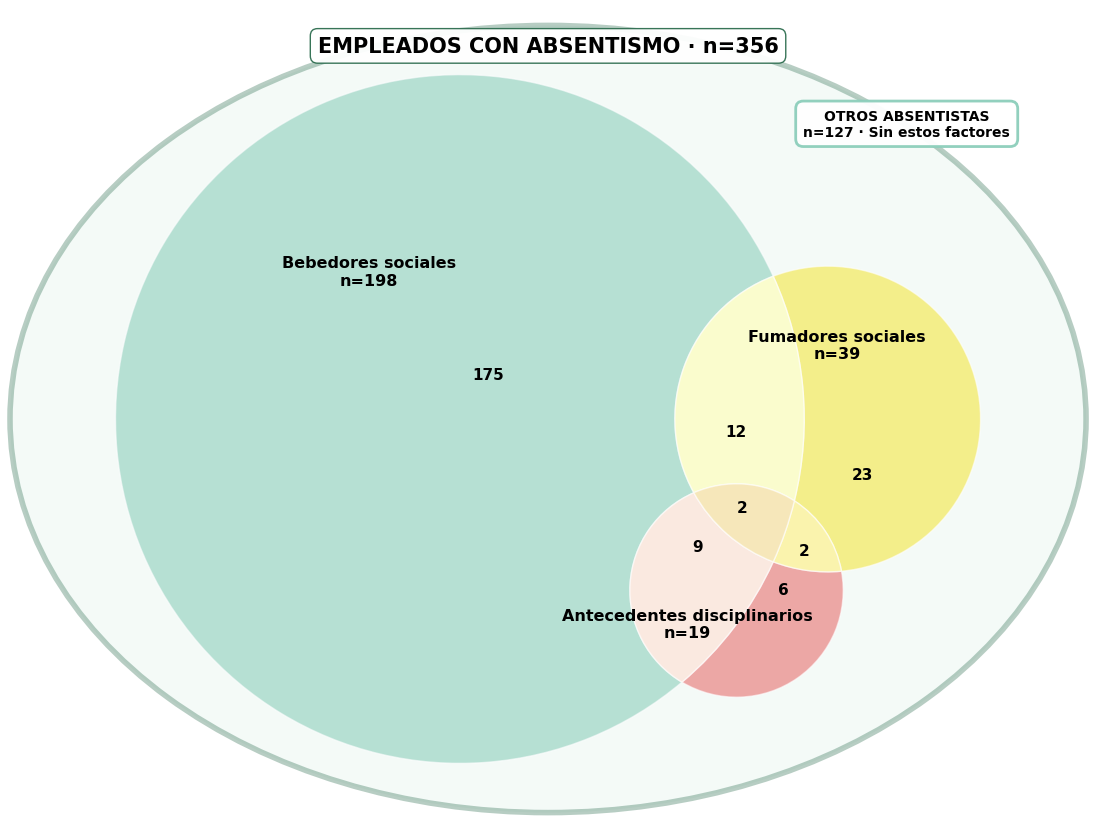

,grupo,empleados
0,Empleados con absentismo,356
1,Dentro de al menos uno de los tres factores,229
2,Otros perfiles con absentismo,127


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib_venn import venn3

# ==================================================
# COLORES
# ==================================================
COLOR_TEXTO = 'black'
COLOR_VERDE_OSCURO = '#2e6e50'
COLOR_VERDE_PRINCIPAL = '#8ecfbc'
COLOR_VERDE_MUY_CLARO = '#dff1ea'

# ==================================================
# PREPARAR DATOS
# ==================================================
grupos_venn = (
    df_RRHH
    .groupby('ID', as_index=False)
    .agg(
        horas_totales_absentismo=('Absenteeism_hours', 'sum'),
        Social_drinker=('Social_drinker', 'first'),
        Social_smoker=('Social_smoker', 'first'),
        Disciplinary_failure=('Disciplinary_failure', 'max')
    )
)

ids_con_absentismo = set(
    grupos_venn.loc[grupos_venn['horas_totales_absentismo'] > 0, 'ID']
)

A = set(
    grupos_venn.loc[
        (grupos_venn['Social_drinker'] == 1)
        & (grupos_venn['horas_totales_absentismo'] > 0),
        'ID'
    ]
)

B = set(
    grupos_venn.loc[
        (grupos_venn['Social_smoker'] == 1)
        & (grupos_venn['horas_totales_absentismo'] > 0),
        'ID'
    ]
)

C = set(
    grupos_venn.loc[
        (grupos_venn['Disciplinary_failure'] == 1)
        & (grupos_venn['horas_totales_absentismo'] > 0),
        'ID'
    ]
)

union_factores = A | B | C
otros_con_absentismo = ids_con_absentismo - union_factores

# ==================================================
# FIGURA
# ==================================================
fig, ax = plt.subplots(figsize=(12, 8.5))
fig.patch.set_alpha(0)
ax.set_facecolor('none')
ax.axis('off')

elipse_absentismo = Ellipse(
    (0.5, 0.5),
    width=1.08,
    height=0.96,
    transform=ax.transAxes,
    facecolor=COLOR_VERDE_MUY_CLARO,
    edgecolor=COLOR_VERDE_OSCURO,
    linewidth=4,
    alpha=0.34,
    zorder=-10,
    clip_on=False
)
ax.add_patch(elipse_absentismo)

# ==================================================
# DIAGRAMA VENN
# ==================================================
v = venn3(
    [A, B, C],
    set_labels=('', '', ''),
    set_colors=('#8ecfbc', '#f5e642', '#e87070'),
    alpha=0.6,
    ax=ax
)

for patch in v.patches:
    if patch is not None:
        patch.set_edgecolor('white')
        patch.set_linewidth(1)

# ==================================================
# MOVER ETIQUETAS NUMÉRICAS
# ==================================================
offsets = {
    '100': (0.2,  0.05),
    '010': (-0.1, -0.1),
    '001': (-0.01, 0.1),
    '110': (0.015, -0.04),
    '101': (0.05, 0.05),
    '011': (-0.015, -0.01),
    '111': (0.0,  0.0),
}

for region_id, (dx, dy) in offsets.items():
    label = v.get_label_by_id(region_id)
    if label is not None:
        x, y = label.get_position()
        label.set_position((x + dx, y + dy))
        label.set_fontsize(11)
        label.set_color('black')
        label.set_fontweight('bold')

for label in v.subset_labels:
    if label is not None:
        label.set_fontsize(11)
        label.set_color('black')
        label.set_fontweight('bold')

# ==================================================
# TÍTULO EXTERIOR
# ==================================================
ax.text(
    0.5,
    0.955,
    f'EMPLEADOS CON ABSENTISMO · n={len(ids_con_absentismo)}',
    transform=ax.transAxes,
    fontsize=15,
    fontweight='bold',
    color='black',
    ha='center',
    va='center',
    bbox={
        'boxstyle': 'round,pad=0.35',
        'facecolor': 'white',
        'edgecolor': COLOR_VERDE_OSCURO,
        'alpha': 0.95
    }
)

# ==================================================
# ETIQUETAS DE LOS CONJUNTOS
# ==================================================
ax.text(
    0.32,
    0.68,
    f'Bebedores sociales\nn={len(A)}',
    transform=ax.transAxes,
    ha='center',
    va='center',
    fontsize=11.5,
    fontweight='bold',
    color='black'
)

ax.text(
    0.79,
    0.59,
    f'Fumadores sociales\nn={len(B)}',
    transform=ax.transAxes,
    ha='center',
    va='center',
    fontsize=11.5,
    fontweight='bold',
    color='black'
)

ax.text(
    0.64,
    0.25,
    f'Antecedentes disciplinarios\nn={len(C)}',
    transform=ax.transAxes,
    ha='center',
    va='center',
    fontsize=11.5,
    fontweight='bold',
    color='black'
)

# ==================================================
# CAJA DE OTROS ABSENTISTAS
# ==================================================
ax.text(
    0.86,
    0.86,
    f'OTROS ABSENTISTAS\nn={len(otros_con_absentismo)} · Sin estos factores',
    transform=ax.transAxes,
    fontsize=10,
    fontweight='bold',
    color='black',
    ha='center',
    va='center',
    bbox={
        'boxstyle': 'round,pad=0.55',
        'facecolor': 'white',
        'edgecolor': COLOR_VERDE_PRINCIPAL,
        'linewidth': 2,
        'alpha': 0.96
    }
)

plt.tight_layout()
plt.savefig(
    'grafica0_venn_grupos.png',
    dpi=150,
    bbox_inches='tight',
    transparent=True
)
plt.show()

resumen_venn = pd.DataFrame({
    'grupo': [
        'Empleados con absentismo',
        'Dentro de al menos uno de los tres factores',
        'Otros perfiles con absentismo'
    ],
    'empleados': [
        len(ids_con_absentismo),
        len(union_factores),
        len(otros_con_absentismo)
    ]
})

resumen_venn

### <span style="font-size:18px; color:olive">**3.2. Distribución de las variables**</span>

In [10]:
def comparar_absentismo(df, variable):
    resultado = (
        df.groupby(variable)['horas_totales']
        .mean()
        .round(2)
        .reset_index()
        .sort_values(by='horas_totales', ascending=False)
    )

    conteo = df[variable].value_counts()

    print("\nRecuento por grupo:")
    print(conteo)

    print("\nAbsentismo medio por grupo:")
    print(resultado)

    plt.figure(figsize=(3, 5))
    plt.gcf().patch.set_alpha(0)
    ax = plt.gca()
    ax.set_facecolor('none')
    sns.barplot(data=resultado, x=variable, y='horas_totales', color='lightsteelblue')
    plt.title(f'Absentismo medio por {variable}')
    plt.ylabel('Horas promedio de absentismo')
    plt.xlabel(variable)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



Recuento por grupo:
Disciplinary_failure
0    341
1     45
Name: count, dtype: int64

Absentismo medio por grupo:
   Disciplinary_failure  horas_totales
1                     1          87.78
0                     0          18.20


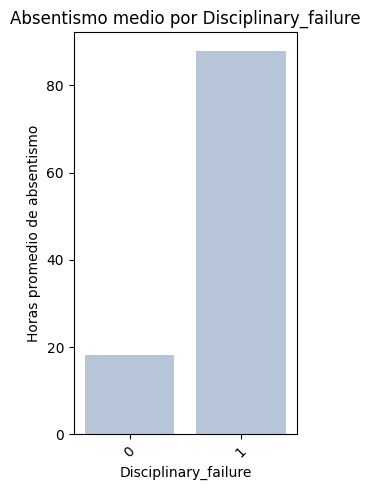

In [11]:
comparar_absentismo(df_empleados, 'Disciplinary_failure')


Recuento por grupo:
Social_drinker
1    218
0    168
Name: count, dtype: int64

Absentismo medio por grupo:
   Social_drinker  horas_totales
1               1          27.30
0               0          25.02


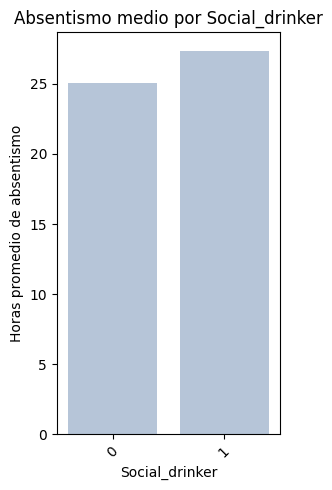

In [12]:
comparar_absentismo(df_empleados, 'Social_drinker')


Recuento por grupo:
Social_smoker
0    340
1     46
Name: count, dtype: int64

Absentismo medio por grupo:
   Social_smoker  horas_totales
0              0          28.06
1              1          13.39


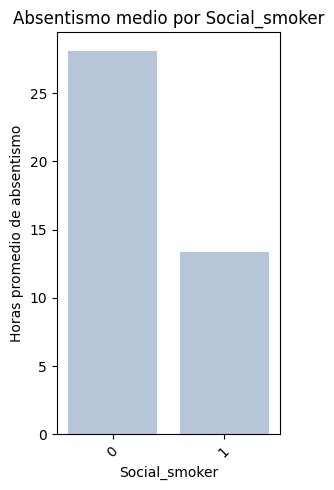

In [13]:
comparar_absentismo(df_empleados, 'Social_smoker')

### <span style="font-size:18px; color:olive">**3.3. Correlaciones entre las variables y el absentismo**</span>

<span style="font-size:14px">Primero recuperamos el enfoque de `analisis_perfil`: comparar absentismo medio por variables categóricas y revisar correlaciones en variables numéricas.</span>

<span style="font-size:14px">La lectura esperada no es causal. Buscamos si alguna variable muestra una diferencia suficientemente clara como para orientar preguntas internas.</span>

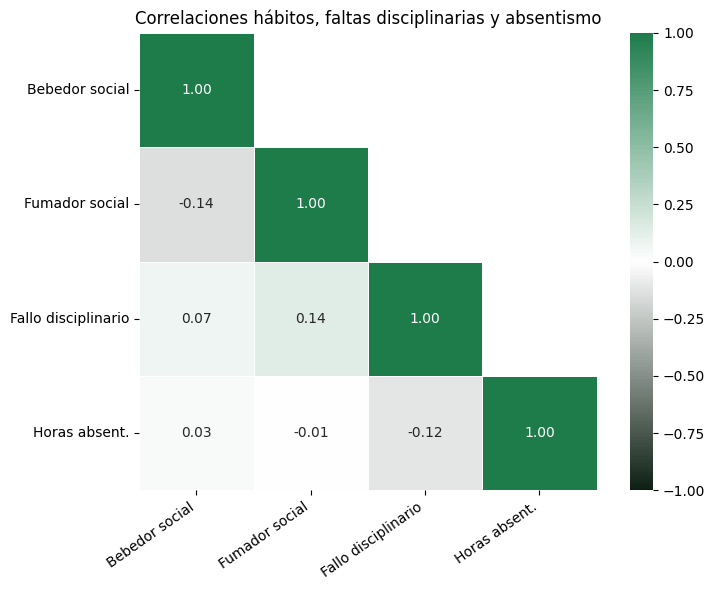

In [14]:
variables_corr = [
    'Social_drinker', 'Social_smoker', 'Disciplinary_failure', 'horas_totales'
]

corr = df_empleados[variables_corr].corr(method='spearman')

labels_es = {
    'Social_drinker': 'Bebedor social',
    'Social_smoker': 'Fumador social',
    'Disciplinary_failure': 'Fallo disciplinario',
    'horas_totales': 'Horas absent.'
}

corr = corr.rename(index=labels_es, columns=labels_es)

cmap_verde = LinearSegmentedColormap.from_list(
    'verde_blanco_verde', ['#0d2014', '#ffffff', '#1e7c4b']
)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(8, 6), facecolor='none')
plt.gcf().patch.set_alpha(0)
ax = sns.heatmap(
    corr, annot=True, fmt='.2f', cmap=cmap_verde, center=0,
    mask=mask, square=True, vmin=-1, vmax=1, linewidths=0.5
)
ax.set_facecolor('none')
plt.title('Correlaciones hábitos, faltas disciplinarias y absentismo')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<span style="font-size:14px; color: orange">**Lectura:**</span> <span style="font-size:14px">las comparaciones por grupos muestran diferencias, pero no bastan para afirmar causalidad. Algunos grupos son pequeños y pueden estar afectados por pocos IDs con muchas horas.</span>

In [15]:
correlacion_absentismo = (
    corr[['Horas absent.']]
    .drop(index='Horas absent.')
    .sort_values('Horas absent.', key=abs, ascending=False)
)

correlacion_absentismo

,Horas absent.
Fallo disciplinario,-0.115538
Bebedor social,0.033716
Fumador social,-0.005882


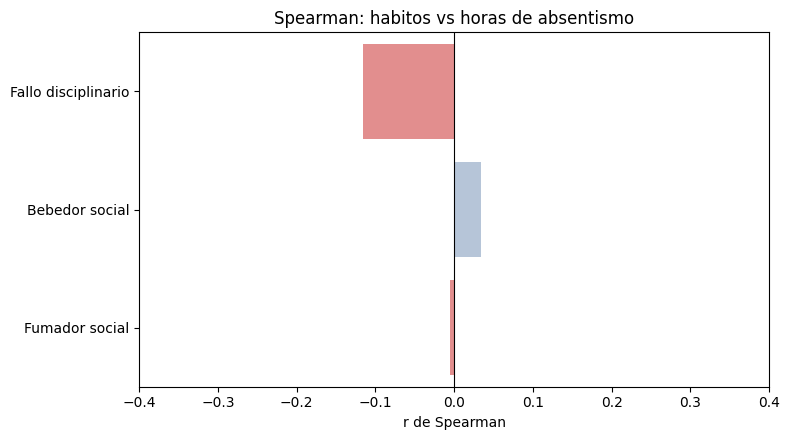

In [16]:
correlacion_plot = (
    correlacion_absentismo
    .reset_index()
    .rename(columns={'index': 'variable', 'Horas absent.': 'r_spearman'})
)

plt.figure(figsize=(8, 4.5))
plt.gcf().patch.set_alpha(0)
ax = plt.gca()
ax.set_facecolor('none')
colores = ['lightsteelblue' if valor >= 0 else 'lightcoral' for valor in correlacion_plot['r_spearman']]

sns.barplot(
    data=correlacion_plot,
    y='variable',
    x='r_spearman',
    palette=colores,
    hue='variable',
    legend=False
)

plt.axvline(0, color='black', linewidth=0.8)
plt.xlim(-0.4, 0.4)
plt.title('Spearman: habitos vs horas de absentismo')
plt.xlabel('r de Spearman')
plt.ylabel('')
plt.tight_layout()
plt.show()

<span style="font-size:14px; color: orange">**Lectura del gráfico Spearman:**</span> <span style="font-size:14px">las barras muestran la fuerza y dirección de la asociación entre cada variable y las horas acumuladas de absentismo. Podemos observar que la correlación por Fallo disciplinario es la más alta, aunque sigue siendo moderada.</span>

<span style="font-size:14px; color: orange">**Lectura:**</span> <span style="font-size:14px">las correlaciones con absentismo son débiles. La señal más alta queda lejos de una relación fuerte, así que no sería riguroso afirmar que una variable personal o laboral explica por sí sola las ausencias.</span>

<span style="font-size:14px">Esto no invalida el análisis. Al contrario: ayuda a descartar una explicación demasiado simple y empuja a mirar segmentos, motivos y concentración de horas.</span>

| Perspectiva          | Conclusión                                                                                                                                     |
| -------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------- |
| <span style="color:#2e6e50; font-size:14px">**Media por grupo**</span>      | <span style="font-size:14px">El fallo disciplinario está asociado a muchísimo más absentismo (~5× más horas)</span>                                                                |
| <span style="color:#5a4e00; font-size:14px">**Correlación Spearman**</span> | <span style="font-size:14px">Al nivel de toda la muestra, la señal es débil porque el grupo afectado es minoritario (n=19)</span>                                                  |
| <span style="color:#6b0000; font-size:14px">**Interpretación real**</span>  | <span style="font-size:14px">El fallo disciplinario sí es relevante como factor de riesgo, pero necesitas un test estadístico ***(Mann-Whitney U)*** para confirmarlo formalmente</span> |

### <span style="font-size:18px; color:olive">**3.4. Mann-Whitney U Test**</span> <span style="font-size:14px">para comparar grupos con y sin cada variable. Es un test no paramétrico que evalúa si las distribuciones de horas de absentismo difieren entre los grupos.</span>

In [17]:
# Como hacer el Mann-Whitney U test para cada variable de hábito vs horas_totales, y mostrar los resultados en un DataFrame ordenado por p-value.
import scipy.stats as stats
variables_habitos = [
    'Social_drinker',
    'Social_smoker',
    'Disciplinary_failure'
]

mann_habitos = []
for variable in variables_habitos:
    grupo_0 = df_empleados[df_empleados[variable] == 0]['horas_totales']
    grupo_1 = df_empleados[df_empleados[variable] == 1]['horas_totales']

    stat, p_value = stats.mannwhitneyu(grupo_0, grupo_1, alternative='two-sided')

    mann_habitos.append({
        'variable': variable,
        'U_statistic': round(stat, 2),
        'p_value': round(p_value, 4),
        'significativo_p_005': 'Sí' if p_value < 0.05 else 'No'
    })

mann_habitos = pd.DataFrame(mann_habitos)
mann_habitos = mann_habitos.sort_values(by='p_value')
mann_habitos

,variable,U_statistic,p_value,significativo_p_005
2,Disciplinary_failure,9248.5,0.0234,Sí
0,Social_drinker,17601.5,0.5086,No
1,Social_smoker,7901.0,0.9087,No


In [18]:
df_empleados['Social_smoker'].value_counts()

Social_smoker
0    340
1     46
Name: count, dtype: int64

<span style="font-size:14px; color: orange">**Según el resultado del test de Mann-Whitney U:**

- <span style="font-size:14px"> `Fumadores sociales` **NO** muestra una diferencia significativa en horas de absentismo entre el grupo de fumadores y el de no fumadores. Pero el grupo de fumadores sociales en comparación con el grupo de NO fumadores sociales es bastante dispar (***46 fumadores sociales vs 340 no fumadores sociales***), por lo que no se puede afirmar que el consumo social de tabaco sea un factor determinante del absentismo.
- <span style="font-size:14px"> `Bebedores sociales` **NO** muestra una diferencia significativa en horas de absentismo entre el grupo de bebedores (***218 empleados***) y el de no bebedores (***168 empleados***), por lo que no se puede afirmar que el consumo social de alcohol sea un factor determinante del absentismo. Aquí los grupos están bastante equilibrados por lo que nos podemos fiar más del resultado estadístico. 
- <span style="font-size:14px"> `Faltas disciplinarias` **SÍ** muestra una diferencia significativa en horas de absentismo entre el grupo con antecedentes disciplinarios y el que no muy importante. Nos la podemos creer totalmente porque aunqué la distribución sea de ***341 empleados sin antecedentes disciplinarios y 45 con antecedentes disciplinarios***, el grupo con antecedentes disciplinarios tiene una media de horas de absentismo mucho más alta que el grupo sin antecedentes disciplinarios. Por lo tanto, se puede afirmar que las faltas disciplinarias son un factor determinante del absentismo.

## <span style="font-size:20px; color:olive">**4. Construcción de absentismo elevado**</span>

In [19]:
df_niveles = df_empleados[df_empleados['horas_totales'] > 0].copy()

orden_niveles = [
    'Bajo (1-3 h)',
    'Medio (4-8 h)',
    'Alto (>8 h)'
]

df_niveles['nivel_absentismo'] = pd.cut(
    df_niveles['horas_totales'],
    bins=[0, 3, 8, np.inf],
    labels=orden_niveles,
    include_lowest=True
)

df_niveles['nivel_absentismo'].value_counts().sort_index()

nivel_absentismo
Bajo (1-3 h)     162
Medio (4-8 h)    128
Alto (>8 h)       66
Name: count, dtype: int64

### <span style="font-size:20px; color:olive">**4.1. Comprovar distribución de los niveles**</span>

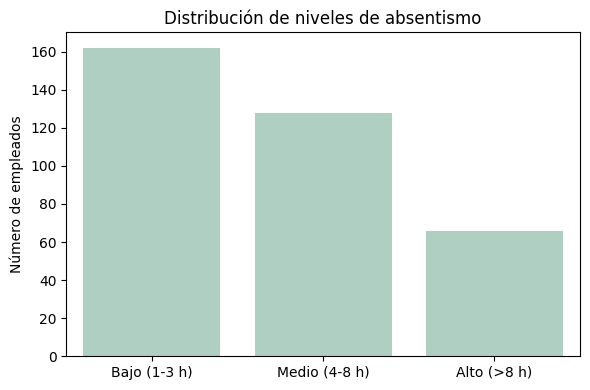

In [20]:
COLOR_VERDE_CLARO = '#A8D5C2'

fig, ax = plt.subplots(figsize=(6, 4), facecolor='none')
ax.set_facecolor('none')

sns.countplot(
    data=df_niveles,
    x='nivel_absentismo',
    order=['Bajo (1-3 h)', 'Medio (4-8 h)', 'Alto (>8 h)'],
    color=COLOR_VERDE_CLARO,
    ax=ax
)

ax.set_title('Distribución de niveles de absentismo')
ax.set_xlabel('')
ax.set_ylabel('Número de empleados')
ax.grid(False)

plt.tight_layout()
plt.show()

#quita 

### <span style="font-size:20px; color:olive">**4.2. Tablas de contingencia por variable**</span> 
<span style="font-size:14px">Las tablas de contingencia permiten analizar la relación entre el nivel de absentismo y otras variables categóricas.</span> <span style="font-size:14px">En este caso, se han construido tablas de contingencia para cada variable categórica (fumador social, bebedor social y antecedentes disciplinarios) en relación con el nivel de absentismo.</span>

   - <span style="color:orange; font-size:14px">**Fumador social:**</span>

In [21]:
tabla_fumador = pd.crosstab(
    df_niveles['nivel_absentismo'],
    df_niveles['Social_smoker'],
    normalize='index'
) * 100

tabla_fumador.round(1)

Social_smoker,0,1
nivel_absentismo,,
Bajo (1-3 h),90.1,9.9
Medio (4-8 h),89.1,10.9
Alto (>8 h),86.4,13.6


 - <span style="color:orange; font-size:14px">**Bebedor social:**</span>

In [22]:
tabla_bebedor = pd.crosstab(
    df_niveles['nivel_absentismo'],
    df_niveles['Social_drinker'],
    normalize='index'
) * 100

tabla_bebedor.round(1)

Social_drinker,0,1
nivel_absentismo,,
Bajo (1-3 h),50.0,50.0
Medio (4-8 h),38.3,61.7
Alto (>8 h),42.4,57.6


 - <span style="color:orange; font-size:14px">**Faltas disciplinarias:**</span>

In [23]:
tabla_disciplina = pd.crosstab(
    df_niveles['nivel_absentismo'],
    df_niveles['Disciplinary_failure'],
    normalize='index'
) * 100

tabla_disciplina.round(1)

Disciplinary_failure,0,1
nivel_absentismo,,
Bajo (1-3 h),100.0,0.0
Medio (4-8 h),99.2,0.8
Alto (>8 h),72.7,27.3


 - <span style="color: rgb(50, 232, 232); font-size:14px">**HEATMAP DE PORCENTAJES:**</span> <span style="font-size:14px">El heatmap muestra la proporción de empleados con absentismo dentro de cada categoría de las variables analizadas. Las celdas más oscuras indican una mayor proporción de empleados con absentismo, lo que sugiere una posible asociación entre esa categoría y el absentismo.</span>

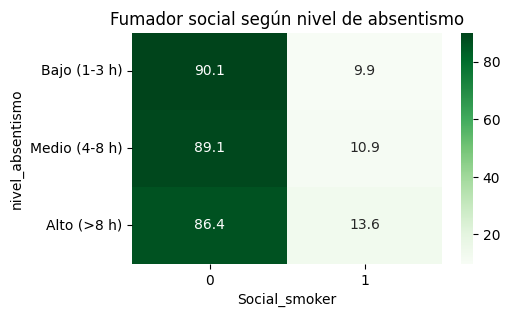

In [24]:
tabla_heatmap = pd.crosstab(
    df_niveles['nivel_absentismo'],
    df_niveles['Social_smoker'],
    normalize='index'
) * 100

plt.figure(figsize=(5,3))

sns.heatmap(
    tabla_heatmap,
    annot=True,
    fmt='.1f',
    cmap='Greens'
)

plt.title('Fumador social según nivel de absentismo')

plt.show()

In [25]:
df_empleados['Social_drinker'].value_counts()

Social_drinker
1    218
0    168
Name: count, dtype: int64

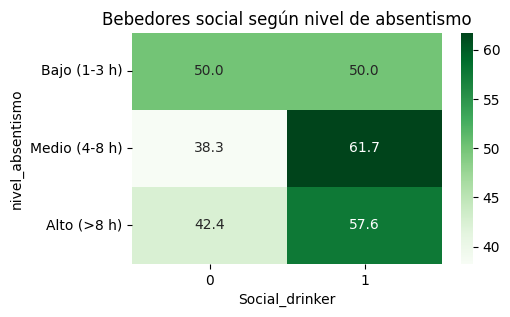

In [26]:
tabla_heatmap = pd.crosstab(
    df_niveles['nivel_absentismo'],
    df_niveles['Social_drinker'],
    normalize='index'
) * 100

plt.figure(figsize=(5,3))

sns.heatmap(
    tabla_heatmap,
    annot=True,
    fmt='.1f',
    cmap='Greens'
)

plt.title('Bebedores social según nivel de absentismo')

plt.show()

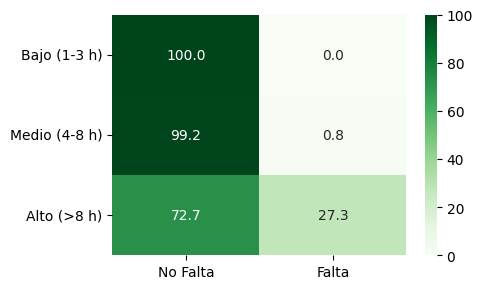

In [27]:
tabla_heatmap = pd.crosstab(
    df_niveles['nivel_absentismo'],
    df_niveles['Disciplinary_failure'],
    normalize='index'
) * 100

plt.figure(figsize=(5, 3), facecolor='none')

ax = sns.heatmap(
    tabla_heatmap,
    annot=True,
    fmt='.1f',
    cmap='Greens'
)

ax.set_facecolor('none')

ax.set_title('')

ax.set_xlabel('')
ax.set_ylabel('')

ax.set_xticklabels(['No Falta', 'Falta'])

plt.tight_layout()
plt.show()



## <span style="font-size:20px; color:olive">**5. Chi-cuadrado:**</span>

<span style="font-size:14px">El test de chi-cuadrado se utiliza para evaluar si existe una asociación significativa entre dos variables categóricas. En este caso, se ha aplicado el test de chi-cuadrado para analizar la relación entre el ***nivel de absentismo*** (elevado o no) y cada una de las variables categóricas (fumador social, bebedor social y antecedentes disciplinarios).</span>

<span style="font-size: 16px; color: teal">**¿La distribución de una variable cambia según otra variable?**</span>

In [30]:
from scipy.stats import chi2_contingency

def test_chi_cuadrado(df, variable):

    tabla = pd.crosstab(
        df['nivel_absentismo'],
        df[variable]
    )

    chi2, p, dof, expected = chi2_contingency(tabla)

    return {
        'variable': variable,
        'chi2': round(chi2,2),
        'p_value': round(p,4),
        'significativo_p_005': 'Sí' if p < 0.05 else 'No'
    }

In [31]:
variables = [
    'Social_smoker',
    'Social_drinker',
    'Disciplinary_failure'
]

chi_results = pd.DataFrame([
    test_chi_cuadrado(df_niveles, var)
    for var in variables
])

chi_results

,variable,chi2,p_value,significativo_p_005
0,Social_smoker,0.68,0.7119,No
1,Social_drinker,4.10,0.1285,No
2,Disciplinary_failure,77.25,0.0000,Sí


<span style="font-size:14px; color: orange">**Observación:**</span> <span style="font-size:14px">El test nos indica que las faltas disciplinarias están significativamente asociadas con el nivel de absentismo. Pero no nos dice como es esa asociación, si es débil o fuerte, ni la dirección de la relación </span> 

<span style="font-size:14px">En este análisis no se incluyen otras variables personales (edad, género, etc.) ni laborales (departamento, antigüedad, etc.) para mantener el foco en el desafío planteado. Sin embargo, podrían explorarse en análisis posteriores.</span> 

### <span style="font-size:20px; color:olive">**5.1. V de Cramer**</span> 

<span style="font-size:14px">El V de Cramer es una medida de asociación que se utiliza para evaluar la fuerza de la relación entre dos variables categóricas. En este caso, se ha calculado el V de Cramer para cada variable categórica (fumador social, bebedor social y antecedentes disciplinarios) en relación con el nivel de absentismo.</span> <span style="font-size:14px">Mide la intensidad de la asociación detectada por el Chi-cuadrado.</span>

In [32]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(tabla):

    chi2 = chi2_contingency(tabla)[0]

    n = tabla.sum().sum()

    r, k = tabla.shape

    return np.sqrt(
        chi2 /
        (n * (min(k-1, r-1)))
    )

In [33]:
for variable in variables:

    tabla = pd.crosstab(
        df_niveles['nivel_absentismo'],
        df_niveles[variable]
    )

    print(
        variable,
        round(cramers_v(tabla),3)
    )

Social_smoker 0.044
Social_drinker 0.107
Disciplinary_failure 0.466


| <span style="font-size:14px; color: teal">**V**</span>         | <span style="font-size:14px; color: orange">**Intensidad**</span> |
| --------- | ---------- |
|<span style="font-size:14px"><0.10</span>     | <span style="font-size:14px; color: orange">Muy débil</span>  |
| <span style="font-size:14px">0.10-0.30</span> | <span style="font-size:14px; color: orange">Débil</span>      |
| <span style="font-size:14px">0.30-0.50</span> | <span style="font-size:14px; color: orange">Moderada</span>   |
| <span style="font-size:14px">>0.50</span>     | <span style="font-size:14px; color: orange">Fuerte</span>     |


   - <span style="font-size:16px">**Visualización de la intensidad de la asociación:**</span>

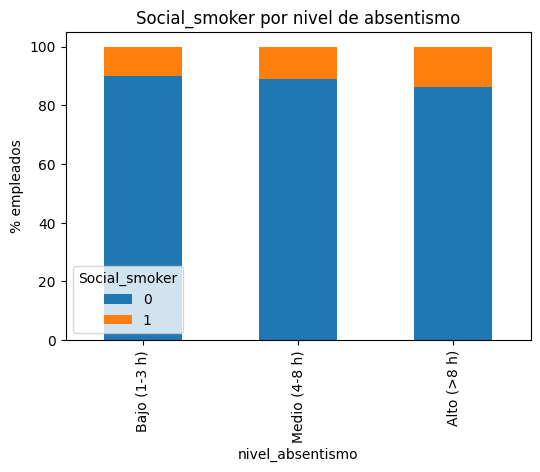

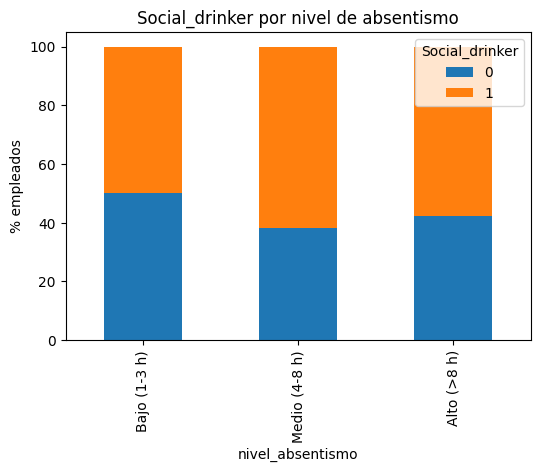

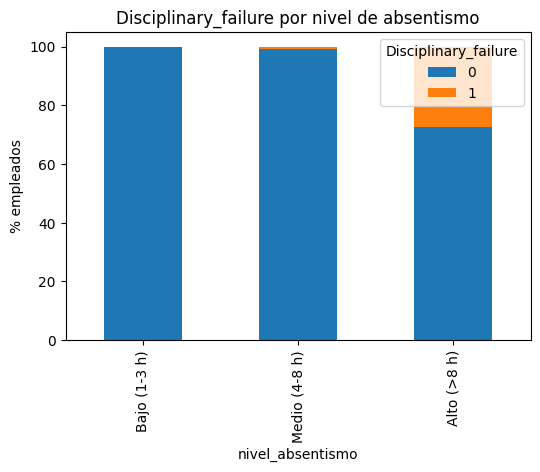

In [35]:
for variable in variables:

    tabla = pd.crosstab(
        df_niveles['nivel_absentismo'],
        df_niveles[variable],
        normalize='index'
    ) * 100

    tabla.plot(
        kind='bar',
        stacked=True,
        figsize=(6,4)
    )

    plt.title(f'{variable} por nivel de absentismo')
    plt.ylabel('% empleados')

    plt.show()

## <span style="color:olive;font-size:20px">**9.5 Regresión logística multinomial regularizada**</span>

<span style="font-size:14px">**La regresión multinomial estima simultáneamente la probabilidad de pertenecer a los niveles `Bajo`, `Medio` y `Alto`, ajustando cada factor por los otros dos.**</span>

<span style="font-size:14px">**Se utiliza regularización L2 porque los antecedentes disciplinarios presentan separación casi perfecta: prácticamente no aparecen en los niveles bajo y medio. Sin regularización, el modelo convencional no converge y produce coeficientes inestables. El valor de regularización se selecciona mediante validación cruzada.**</span>

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    balanced_accuracy_score,
    log_loss,
    roc_auc_score,
    brier_score_loss
)

X_multinomial = df_niveles[variables].astype(float)
y_multinomial = df_niveles['nivel_absentismo'].map(str)

# Esta tabla evidencia la separación que justifica regularizar el modelo.
tabla_separacion = pd.crosstab(
    df_niveles['Disciplinary_failure'],
    df_niveles['nivel_absentismo']
)
display(tabla_separacion)

cv_modelos = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
valores_C = [0.01, 0.1, 1, 10, 100]
evaluacion_multinomial = []

for C in valores_C:
    modelo_candidato = LogisticRegression(
        C=C,
        penalty='l2',
        solver='lbfgs',
        max_iter=5000
    )
    probabilidades_cv = cross_val_predict(
        modelo_candidato,
        X_multinomial,
        y_multinomial,
        cv=cv_modelos,
        method='predict_proba'
    )
    clases_cv = np.sort(y_multinomial.unique())
    predicciones_cv = clases_cv[probabilidades_cv.argmax(axis=1)]

    evaluacion_multinomial.append({
        'C': C,
        'log_loss_cv': log_loss(
            y_multinomial,
            probabilidades_cv,
            labels=clases_cv
        ),
        'balanced_accuracy_cv': balanced_accuracy_score(
            y_multinomial,
            predicciones_cv
        )
    })

evaluacion_multinomial = pd.DataFrame(evaluacion_multinomial)
C_multinomial = evaluacion_multinomial.loc[
    evaluacion_multinomial['log_loss_cv'].idxmin(),
    'C'
]

modelo_multinomial = LogisticRegression(
    C=C_multinomial,
    penalty='l2',
    solver='lbfgs',
    max_iter=5000
).fit(X_multinomial, y_multinomial)

coeficientes_multinomial = pd.DataFrame(
    modelo_multinomial.coef_,
    index=modelo_multinomial.classes_,
    columns=variables
)

display(evaluacion_multinomial)
print('C seleccionado:', C_multinomial)
display(coeficientes_multinomial.round(3))


nivel_absentismo,Bajo (1-3 h),Medio (4-8 h),Alto (>8 h)
Disciplinary_failure,,,
0,162,127,48
1,0,1,18


c:\Users\dioul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\dioul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\dioul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

,C,log_loss_cv,balanced_accuracy_cv
0,0.01,1.031638,0.333333
1,0.10,0.998821,0.423824
2,1.00,0.968370,0.413890
3,10.00,0.966703,0.413890
4,100.00,0.971224,0.413890


C seleccionado: 10.0


,Social_smoker,Social_drinker,Disciplinary_failure
Alto (>8 h),0.050,0.047,3.087
Bajo (1-3 h),-0.137,-0.272,-2.399
Medio (4-8 h),0.088,0.225,-0.688


,factor,nivel_absentismo,probabilidad_factor_0,probabilidad_factor_1,diferencia_puntos_porcentuales
7,Disciplinary_failure,Bajo (1-3 h),0.480,0.013,-46.652
8,Disciplinary_failure,Medio (4-8 h),0.377,0.056,-32.110
6,Disciplinary_failure,Alto (>8 h),0.143,0.931,78.763
4,Social_drinker,Bajo (1-3 h),0.514,0.408,-10.546
5,Social_drinker,Medio (4-8 h),0.308,0.401,9.377
3,Social_drinker,Alto (>8 h),0.179,0.191,1.169
1,Social_smoker,Bajo (1-3 h),0.460,0.410,-4.992
2,Social_smoker,Medio (4-8 h),0.355,0.396,4.009
0,Social_smoker,Alto (>8 h),0.184,0.194,0.983


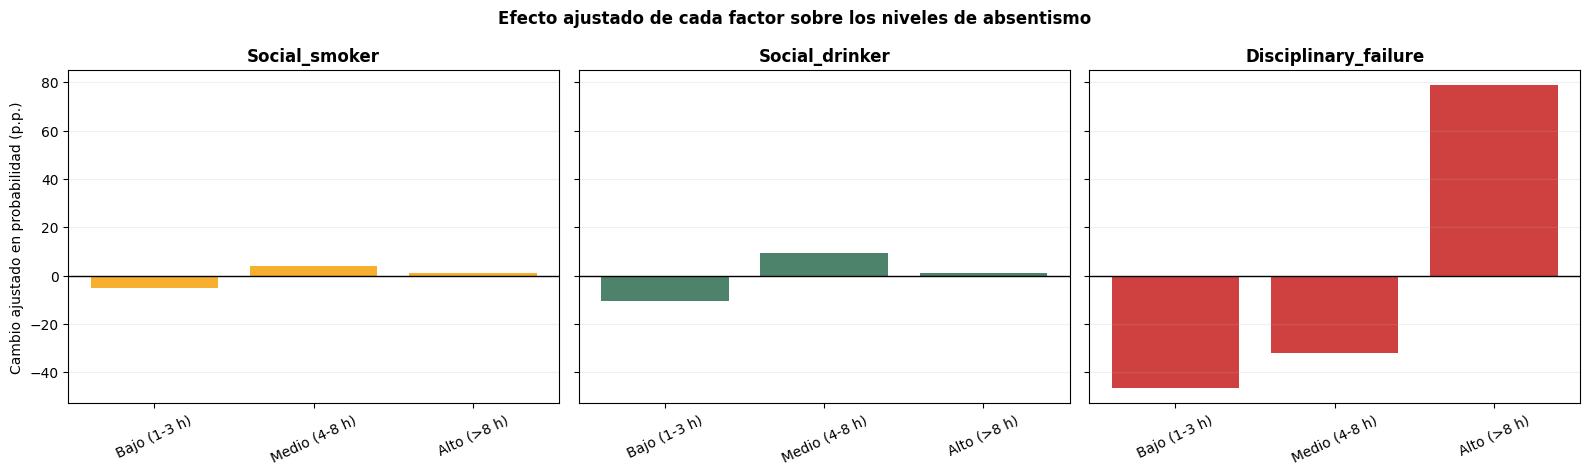

In [45]:
# Efectos ajustados: cambio medio en probabilidad al pasar cada factor
# de 0 a 1, manteniendo los otros factores como se observan en la muestra.
efectos_multinomial = []

for factor in variables:
    escenario_0 = X_multinomial.copy()
    escenario_1 = X_multinomial.copy()
    escenario_0[factor] = 0
    escenario_1[factor] = 1

    probabilidad_0 = modelo_multinomial.predict_proba(escenario_0).mean(axis=0)
    probabilidad_1 = modelo_multinomial.predict_proba(escenario_1).mean(axis=0)

    for posicion, nivel in enumerate(modelo_multinomial.classes_):
        efectos_multinomial.append({
            'factor': factor,
            'nivel_absentismo': nivel,
            'probabilidad_factor_0': probabilidad_0[posicion],
            'probabilidad_factor_1': probabilidad_1[posicion],
            'diferencia_puntos_porcentuales': (
                probabilidad_1[posicion] - probabilidad_0[posicion]
            ) * 100
        })

efectos_multinomial_df = pd.DataFrame(efectos_multinomial)
efectos_multinomial_df['nivel_absentismo'] = pd.Categorical(
    efectos_multinomial_df['nivel_absentismo'],
    categories=orden_niveles,
    ordered=True
)
efectos_multinomial_df = efectos_multinomial_df.sort_values(
    ['factor', 'nivel_absentismo']
)

display(efectos_multinomial_df.round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)

for ax, factor in zip(axes, variables):
    datos_factor = efectos_multinomial_df[
        efectos_multinomial_df['factor'] == factor
    ]
    colores = [
        '#C71F1F' if factor == 'Disciplinary_failure'
        else '#F5A20A' if factor == 'Social_smoker'
        else COLOR_VERDE_OSCURO
    ] * len(datos_factor)

    ax.bar(
        datos_factor['nivel_absentismo'].astype(str),
        datos_factor['diferencia_puntos_porcentuales'],
        color=colores,
        alpha=0.85
    )
    ax.axhline(0, color=COLOR_TEXTO, linewidth=1)
    ax.set_title(factor, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', alpha=0.2)
    ax.set_facecolor('none')

axes[0].set_ylabel('Cambio ajustado en probabilidad (p.p.)')
fig.suptitle(
    'Efecto ajustado de cada factor sobre los niveles de absentismo',
    fontweight='bold'
)
fig.patch.set_alpha(0)
plt.tight_layout()
plt.show()

<span style="color: orange; font-size:16px">**Lectura multinomial:**</span> <span style="font-size:14px">el modelo ajustado confirma que alcohol y tabaco apenas modifican la probabilidad estimada de pertenecer al nivel alto.</span>
<span style="font-size:14px">Los antecedentes disciplinarios concentran una gran variación hacia el nivel alto, incluso después de ajustar por los dos hábitos sociales.</span>

<span style="font-size:14px">La capacidad predictiva global es limitada y el resultado disciplinario depende de pocos casos concentrados. 
Por ello, el modelo se utiliza para explicar la asociación observada, no para clasificar empleados ni tomar decisiones individuales.</span>

## <span style="color: olive; font-size:20px">**9.6 Regresión logística binaria de sensibilidad**</span>

<span style="font-size:14px">Como comprobación adicional, se modela la pertenencia al nivel `Alto (>8 h)` frente a los niveles bajo y medio. Esta regresión simplifica el resultado y
permite evaluar si las conclusiones cambian al centrarse únicamente en el grupo de mayor impacto.</span>

In [46]:
df_modelo_alto = df_niveles.copy()
df_modelo_alto['nivel_alto'] = (
    df_modelo_alto['nivel_absentismo'] == 'Alto (>8 h)'
).astype(int)

X_alto = df_modelo_alto[variables].astype(float)
y_alto = df_modelo_alto['nivel_alto']
evaluacion_logistica_alto = []

for C in valores_C:
    modelo_candidato = LogisticRegression(
        C=C,
        penalty='l2',
        solver='lbfgs',
        max_iter=5000
    )
    probabilidad_cv = cross_val_predict(
        modelo_candidato,
        X_alto,
        y_alto,
        cv=cv_modelos,
        method='predict_proba'
    )[:, 1]
    prediccion_cv = (probabilidad_cv >= 0.5).astype(int)

    evaluacion_logistica_alto.append({
        'C': C,
        'log_loss_cv': log_loss(y_alto, probabilidad_cv),
        'roc_auc_cv': roc_auc_score(y_alto, probabilidad_cv),
        'balanced_accuracy_cv': balanced_accuracy_score(
            y_alto,
            prediccion_cv
        ),
        'brier_score_cv': brier_score_loss(y_alto, probabilidad_cv)
    })

evaluacion_logistica_alto = pd.DataFrame(evaluacion_logistica_alto)
C_logistica_alto = evaluacion_logistica_alto.loc[
    evaluacion_logistica_alto['log_loss_cv'].idxmin(),
    'C'
]

modelo_logistica_alto = LogisticRegression(
    C=C_logistica_alto,
    penalty='l2',
    solver='lbfgs',
    max_iter=5000
).fit(X_alto, y_alto)

odds_ratio_regularizadas = pd.DataFrame({
    'factor': variables,
    'coeficiente_regularizado': modelo_logistica_alto.coef_[0],
    'odds_ratio_regularizada': np.exp(modelo_logistica_alto.coef_[0])
})

display(evaluacion_logistica_alto)
print('C seleccionado:', C_logistica_alto)
display(odds_ratio_regularizadas.round(3))


c:\Users\dioul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\dioul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\dioul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

,C,log_loss_cv,roc_auc_cv,balanced_accuracy_cv,brier_score_cv
0,0.01,0.475241,0.639734,0.500000,0.149707
1,0.10,0.447800,0.622753,0.500000,0.139295
2,1.00,0.408162,0.608438,0.634639,0.121025
3,10.00,0.403022,0.606609,0.634639,0.119041
4,100.00,0.407210,0.606609,0.634639,0.119039


C seleccionado: 10.0


,factor,coeficiente_regularizado,odds_ratio_regularizada
0,Social_smoker,0.091,1.096
1,Social_drinker,0.097,1.102
2,Disciplinary_failure,4.299,73.611


<span style="font-size:16px; color: orange">**Lectura de sensibilidad:**</span> <span style="font-size:14px">la regresión binaria reproduce la misma conclusión sustantiva: los antecedentes disciplinarios son la principal señal asociada al nivel alto; alcohol y tabaco aportan poca capacidad explicativa.</span>

<span style="font-size:14px">Las métricas de validación cruzada muestran que los tres factores, por sí solos, no permiten predecir adecuadamente quién pertenecerá al nivel alto. Faltan variables laborales, temporales y sobre el motivo de ausencia.</span>